In [1]:
import numpy as np
import cv2
import matplotlib.pyplot as plt

In [30]:
def add_noise(image, sigma_normalized=0.15):
    """Añade ruido gaussiano a la imagen normalizada."""
    noise = np.random.normal(0, sigma_normalized, image.shape)
    noisy_img = image + noise
    return np.clip(noisy_img, 0.0, 1.0).astype(np.float32)

def gibbs_implicit_segmentation(noisy_img, burn_in=10, samplings=10, 
                                sigma=0.15, beta=2.5):
    """
    Algoritmo unificado de Gibbs.
    Utiliza Variación Total (L-1) fuerte para crear regiones planas y bordes definidos,
    logrando limpieza y segmentación implícita simultáneamente.
    """
    M, N = noisy_img.shape
    Y = np.copy(noisy_img)
    
    # Espacio de estados: 100 niveles de intensidad continua
    levels_Y = np.linspace(0, 1, 20) 
    states_Y = levels_Y.reshape(-1, 1)
    
    # Desplazamientos para la vecindad 3x3
    dy = [-1, -1, -1,  0, 0,  1, 1, 1]
    dx = [-1,  0,  1, -1, 1, -1, 0, 1]
    
    samples_Y = []
    total_iterations = burn_in + samplings
    
    print("Iniciando Muestreo de Gibbs")
    for it in range(total_iterations):
        fase = "Burn-in" if it < burn_in else "Sampling"
        print(f"Iteración {it + 1}/{total_iterations} ({fase})")
        
        # Actualización píxel por píxel
        for i in range(1, M - 1):
            for j in range(1, N - 1):
                x_ij = noisy_img[i, j]
                
                y_neighbors = np.array([Y[i+dy[k], j+dx[k]] for k in range(8)])
                
                # Ecuación de Energía: Observación + Prior de Variación Total (L-1)
                u_obs = ((states_Y - x_ij)**2) / (2 * sigma**2)
                u_prior = beta * np.sum(np.abs(states_Y - y_neighbors), axis=1, keepdims=True)
                
                energy = (u_obs + u_prior).flatten()
                
                # Transformación a probabilidad y muestreo Monte Carlo
                energy -= np.min(energy) # Prevención de underflow exponencial
                probs = np.exp(-energy)
                probs /= np.sum(probs)
                
                Y[i, j] = levels_Y[np.random.choice(len(levels_Y), p=probs)]
                
        # "Después de un número suficiente de iteraciones, el método genera una 
        # colección de imágenes restauradas plausibles."
        if it >= burn_in:
            samples_Y.append(np.copy(Y))
            
    print("Construyendo reconstrucción final...")
    # "A partir de esas realizaciones se construye una reconstrucción final."
    Y_final = np.mean(samples_Y, axis=0)
    
    return Y_final

In [45]:

img_path = 'loros2.jpg'
img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)

# Redimensionar para tratabilidad computacional en la prueba
img = cv2.resize(img, (100, 100))
img = img / 255.0 

noisy_image = add_noise(img, sigma_normalized=0.1) 

final_reconstruction = gibbs_implicit_segmentation(
    noisy_image, 
    burn_in=100, 
    samplings=10000,
    sigma=0.08,
    beta=2.5 
)

Iniciando Muestreo de Gibbs
Iteración 1/10100 (Burn-in)
Iteración 2/10100 (Burn-in)
Iteración 3/10100 (Burn-in)
Iteración 4/10100 (Burn-in)
Iteración 5/10100 (Burn-in)
Iteración 6/10100 (Burn-in)
Iteración 7/10100 (Burn-in)
Iteración 8/10100 (Burn-in)
Iteración 9/10100 (Burn-in)
Iteración 10/10100 (Burn-in)
Iteración 11/10100 (Burn-in)
Iteración 12/10100 (Burn-in)
Iteración 13/10100 (Burn-in)
Iteración 14/10100 (Burn-in)
Iteración 15/10100 (Burn-in)
Iteración 16/10100 (Burn-in)
Iteración 17/10100 (Burn-in)
Iteración 18/10100 (Burn-in)
Iteración 19/10100 (Burn-in)
Iteración 20/10100 (Burn-in)
Iteración 21/10100 (Burn-in)
Iteración 22/10100 (Burn-in)
Iteración 23/10100 (Burn-in)
Iteración 24/10100 (Burn-in)
Iteración 25/10100 (Burn-in)
Iteración 26/10100 (Burn-in)
Iteración 27/10100 (Burn-in)
Iteración 28/10100 (Burn-in)
Iteración 29/10100 (Burn-in)
Iteración 30/10100 (Burn-in)
Iteración 31/10100 (Burn-in)
Iteración 32/10100 (Burn-in)
Iteración 33/10100 (Burn-in)
Iteración 34/10100 (Burn

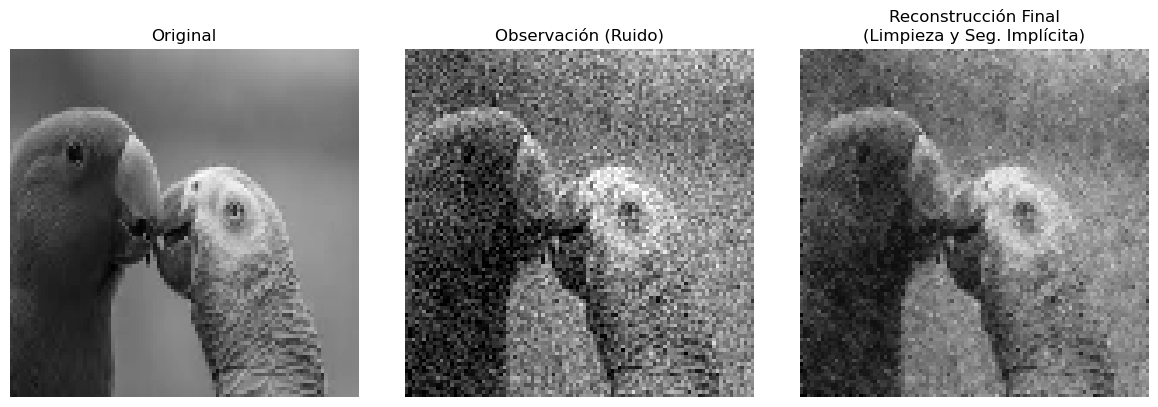

In [47]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.title('Original')
plt.imshow(img, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 3, 2)
plt.title('Observación (Ruido)')
plt.imshow(noisy_image, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.subplot(1, 3, 3)
plt.title('Reconstrucción Final\n(Limpieza y Seg. Implícita)')
plt.imshow(final_reconstruction, cmap='gray', vmin=0, vmax=1)
plt.axis('off')

plt.tight_layout()
plt.show()